<a href="https://colab.research.google.com/github/mauroangeletti-lab/Enzyme_analysis/blob/main/Bieth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ FIT SUCCESS:
   Ki_app = 24.47 ± 1.18 nM
   [E]_tot = 34.7 ± 2.6 nM
   R² = 0.9997


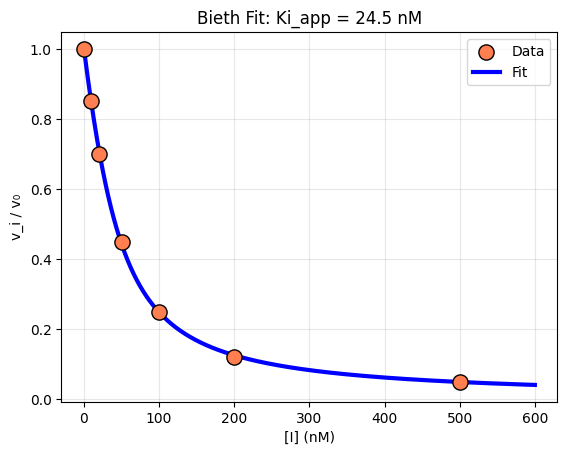

In [1]:

# Fitting data of enzyme activity a vs. inhibitor concentration [I], using equation by Bieth 1974, m.angeletti 2026
# Bieth, J. (1974). Some Kinetic Consequences of the Tight Binding of Protein-Proteinase-Inhibitors to Proteolytic Enzymes and their Application to the Determination of Dissociation Constants. In: Fritz, H., Tschesche, H., Greene, L.J., Truscheit, E. (eds) Proteinase Inhibitors. Bayer-Symposium, vol 5. Springer, Berlin, Heidelberg. https://doi.org/10.1007/978-3-642-87966-1_52
# add your data below



import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns
import pandas as pd # Import pandas



# YOUR DATA HERE. (for [I] you can use whatever dimension molar or g/L or similar)
I = np.array([0, 10, 20, 50, 100, 200, 500])
a = np.array([1.0, 0.85, 0.70, 0.45, 0.25, 0.12, 0.05])
# END OF YOUR DATA

# MORRISON STABILIZED 
def morrison_stable(I, Ki_app, E_tot):
    """
    v_i/v_0 = [E + Ki + I - sqrt((E + Ki + I)^2 - 4 E I)] / (2 E)
    Numerica stabile per Ki, E piccoli
    """
    discriminant = (E_tot + Ki_app + I)**2 - 4 * E_tot * I
    num = E_tot + Ki_app + I - np.sqrt(np.maximum(discriminant, 0))
    return 1-num / (2 * E_tot)

# ROBUST FIT
p0 = [60, 60]  # guess [Ki_app, E_tot]
bounds = ([1, 20], [100, 300])  # larger BUT positive bounds 

popt, pcov = curve_fit(morrison_stable, I, a, p0=p0, bounds=bounds,
                       maxfev=10000, method='dogbox')

Ki_app, E_tot = popt
perr = np.sqrt(np.diag(pcov))

R2 = 1 - np.sum((a - morrison_stable(I, *popt))**2) / np.sum((a - np.mean(a))**2)

print(f"✅ FIT SUCCESS:")
print(f"   Ki_app = {Ki_app:.2f} ± {perr[0]:.2f} nM")
print(f"   [E]_tot = {E_tot:.1f} ± {perr[1]:.1f} nM")
print(f"   R² = {R2:.4f}")

# Plot
I_plot = np.linspace(0, 600, 1000)
plt.scatter(I, a, s=120, color='coral', edgecolor='black', zorder=5)
plt.plot(I_plot, morrison_stable(I_plot, *popt), 'b-', lw=3)
plt.xlabel('[I] (nM)')
plt.ylabel('v_i / v₀')
plt.title(f'Bieth Fit: Ki_app = {Ki_app:.1f} nM')
plt.grid(alpha=0.3)
plt.legend(['Data', 'Fit'])
plt.show()